<a href="https://colab.research.google.com/github/akritib25/FoodSafety/blob/main/Foodsafety.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Cell 1 — install and import
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn'],
               capture_output=True)

import pandas as pd
import numpy as np



In [18]:
# Cell 2 — download directly from SCC open data (no upload needed)
print("Downloading inspections...")
inspections = pd.read_csv('https://data.sccgov.org/api/views/2u2d-8jej/rows.csv?accessType=DOWNLOAD')
print(f"Inspections: {inspections.shape}")
print(inspections.columns.tolist())

print("\nDownloading violations...")
violations = pd.read_csv('https://data.sccgov.org/api/views/wkaa-4ccv/rows.csv?accessType=DOWNLOAD')
print(f"Violations: {violations.shape}")
print(violations.columns.tolist())

Inspections: (23158, 8)
['business_id', 'inspection_id', 'date', 'SCORE', 'result', 'description', 'type', 'inspection_comment']

Violations: (63961, 5)
['inspection_id', 'DESCRIPTION', 'code', 'critical', 'violation_comment']


In [19]:
# Cell 3 — download, normalize, combine all years
import requests
import pandas as pd
import numpy as np
from io import StringIO

# --- download current dataset ---
print("Downloading current dataset...")
r = requests.get("https://data.sccgov.org/api/views/2u2d-8jej/rows.csv?accessType=DOWNLOAD")
current = pd.read_csv(StringIO(r.text), dtype=str)
current = current.rename(columns={'SCORE':'score'})
current = current[['inspection_id','date','type','business_id','result','score']].copy()

# --- download historical datasets ---
hist = {
    '2021': '4k9d-9aaq',
    '2020': 'qgpi-33gi',
    '2017': 'vip6-hb5z',
}

frames = [current]

for year, did in hist.items():
    print("Downloading " + year + "...")
    url = "https://data.sccgov.org/api/views/" + did + "/rows.csv?accessType=DOWNLOAD"
    r2  = requests.get(url, timeout=30)
    df2 = pd.read_csv(StringIO(r2.text), dtype=str)
    df2 = df2.rename(columns={
        'ACTIVITY_NUMBER':    'inspection_id',
        'ACTIVITY_DATE':      'date',
        'INSPECTION_TYPE':    'type',
        'PROGRAM_IDENTIFIER': 'business_id',
        'PlacardColor':       'result',
        'PLACARD_COLOR':      'result',
        'Score':              'score',
        'SCORE':              'score',
    })
    keep = ['inspection_id','date','type','business_id','result','score']
    df2  = df2[[c for c in keep if c in df2.columns]].copy()
    frames.append(df2)

# --- combine and clean ---
combined = pd.concat(frames, ignore_index=True)
combined = combined.drop_duplicates(subset='inspection_id')
combined['date']  = pd.to_datetime(combined['date'], errors='coerce')
combined['score'] = pd.to_numeric(combined['score'], errors='coerce')
combined = combined.dropna(subset=['date'])
combined = combined.sort_values('date').reset_index(drop=True)

# normalize result column
combined['result'] = combined['result'].str.upper().str.strip()
combined['result'] = combined['result'].replace({'GREEN':'G','YELLOW':'Y','RED':'R'})

print("\nCombined:", combined.shape)
print("Date range:", combined['date'].min().date(), "to", combined['date'].max().date())
print("Facilities:", combined['business_id'].nunique())
print("Result counts:\n", combined['result'].value_counts())


Combined: (23158, 6)
Date range: 2024-05-27 to 2026-05-22
Facilities: 9683
Result counts:
 result
G    20987
Y     1251
R      855
Name: count, dtype: int64


In [20]:
# Cell 4 — normalize result column + merge violations
combined['result_clean'] = combined['result'].str.upper().str.strip()
combined['result_clean'] = combined['result_clean'].replace({
    'GREEN': 'G', 'YELLOW': 'Y', 'RED': 'R'
})

# merge violations
viol_counts = violations.groupby('inspection_id').agg(
    major_count = ('critical', lambda x: x.astype(str).str.upper().str.strip().eq('TRUE').sum()),
    total_viols = ('DESCRIPTION', 'count')
).reset_index()

df = combined.merge(viol_counts, on='inspection_id', how='left')
df['major_count'] = df['major_count'].fillna(0)
df['total_viols'] = df['total_viols'].fillna(0)
df['score']       = pd.to_numeric(df['score'], errors='coerce')

# routine only with valid score
routine = df[
    df['type'].str.contains('ROUTINE', case=False, na=False) &
    df['score'].notna()
].copy()

print(f"Routine inspections: {len(routine)}")
print(f"Unique facilities:   {routine['business_id'].nunique()}")
print(f"Major violation rate: {(routine['major_count']>0).mean()*100:.1f}%")

Routine inspections: 19092
Unique facilities:   9587
Major violation rate: 31.2%


In [21]:
# Cell 5 — compute lag features per facility
routine = routine.sort_values(['business_id','date'])
routine['prev_date']  = routine.groupby('business_id')['date'].shift(1)
routine['prev_score'] = routine.groupby('business_id')['score'].shift(1)
routine['days_since'] = (routine['date'] - routine['prev_date']).dt.days
routine['had_major']  = routine['major_count'] > 0

# drop first inspection per facility (no prior data)
routine = routine.dropna(subset=['days_since','prev_score']).copy()

print(f"Inspections with lag data: {len(routine)}")
print(f"Avg days between inspections: {routine['days_since'].mean():.0f}")
print(f"Major violation rate: {routine['had_major'].mean()*100:.1f}%")
print(routine[['business_id','date','score','days_since','major_count','had_major']].head(5))

Inspections with lag data: 9505
Avg days between inspections: 283
Major violation rate: 31.0%
      business_id       date  score  days_since  major_count  had_major
17223   PR0300002 2025-12-02   96.0       368.0          0.0      False
13200   PR0300005 2025-08-14   66.0       338.0          2.0       True
22726   PR0300005 2026-05-07   78.0       266.0          1.0       True
20813   PR0300007 2026-03-05   74.0       267.0          2.0       True
9684    PR0300010 2025-05-09   95.0       325.0          0.0      False


In [30]:
# Cell 6 — corrected split
train = routine[routine['date'] < '2025-07-01'].copy()
test  = routine[routine['date'] >= '2025-07-01'].copy()

print(f"Train: {len(train):,} ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test:  {len(test):,}  ({test['date'].min().date()} to {test['date'].max().date()})")
print(f"Major violations in train: {train['had_major'].sum()} ({train['had_major'].mean()*100:.1f}%)")
print(f"Major violations in test:  {test['had_major'].sum()} ({test['had_major'].mean()*100:.1f}%)")

Train: 1,819 (2024-06-19 to 2025-06-30)
Test:  7,686  (2025-07-01 to 2026-05-22)
Major violations in train: 509 (28.0%)
Major violations in test:  2435 (31.7%)


In [31]:
# Cell 7 — M0: chronological baseline
def simulate_m0(test_df, interval_days=180):
    caught, missed = [], []
    for _, row in test_df.iterrows():
        scheduled = row['days_since'] >= interval_days
        if row['had_major']:
            (caught if scheduled else missed).append(row['days_since'])
    total   = len(caught) + len(missed)
    rate    = len(caught) / total * 100 if total else 0
    avg_days = np.mean(caught) if caught else 0
    print(f"M0 Baseline — Catch rate: {rate:.1f}%  |  Avg days to detection: {avg_days:.1f}  |  Missed: {len(missed)}")
    return rate, avg_days

m0_rate, m0_days = simulate_m0(test)

M0 Baseline — Catch rate: 89.7%  |  Avg days to detection: 329.7  |  Missed: 250


In [32]:
# Cell 8 — M1: static ML (GradientBoosting)
from sklearn.ensemble import GradientBoostingClassifier

feats = ['score','days_since','major_count','total_viols','prev_score']
tr = train[feats + ['had_major']].dropna()
te = test[feats  + ['had_major']].dropna().copy()

m1 = GradientBoostingClassifier(n_estimators=100, random_state=42)
m1.fit(tr[feats], tr['had_major'].astype(int))

te['risk'] = m1.predict_proba(te[feats])[:,1]
threshold  = te['risk'].quantile(0.70)
te['scheduled'] = te['risk'] >= threshold

maj = te[te['had_major']]
m1_rate = maj['scheduled'].mean() * 100
m1_days = maj[maj['scheduled']]['days_since'].mean()
print(f"M1 Static ML  — Catch rate: {m1_rate:.1f}%  |  Avg days to detection: {m1_days:.1f}")

M1 Static ML  — Catch rate: 100.0%  |  Avg days to detection: 310.2


In [38]:
# Cell 8b — add cross-facility validation to M1
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    tr[feats], tr['had_major'].astype(int),
    cv=5, scoring='recall'
)
print("M1 cross-validated recall:", round(scores.mean()*100,1), "% (+/-", round(scores.std()*100,1), ")")

M1 cross-validated recall: 100.0 % (+/- 0.0 )


In [43]:
# Cell 8c — demonstrate M1 overfitting
train_facilities = set(train['business_id'].unique())

# use test (full) not te (feature-filtered)
test_with_pred = test[feats + ['had_major','business_id']].dropna().copy()
test_with_pred['risk']      = m1.predict_proba(test_with_pred[feats])[:,1]
test_with_pred['scheduled'] = test_with_pred['risk'] >= threshold

test_unseen = test_with_pred[~test_with_pred['business_id'].isin(train_facilities)]
test_seen   = test_with_pred[ test_with_pred['business_id'].isin(train_facilities)]

print("Facilities seen in training:  ", len(test_seen))
print("Facilities unseen in training:", len(test_unseen))

if len(test_unseen) > 0:
    unseen_rate = test_unseen[test_unseen['had_major']]['scheduled'].mean() * 100
    seen_rate   = test_seen[test_seen['had_major']]['scheduled'].mean() * 100
    print("\nM1 catch rate on SEEN facilities:  ", round(seen_rate,1), "%")
    print("M1 catch rate on UNSEEN facilities:", round(unseen_rate,1), "%")
else:
    print("\nAll test facilities were seen in training — pure memorization confirmed.")

Facilities seen in training:   2217
Facilities unseen in training: 5469

M1 catch rate on SEEN facilities:   0.0 %
M1 catch rate on UNSEEN facilities: 0.0 %


In [46]:
# Cell 8c fixed
train_facilities = set(train['business_id'].unique())

test_with_pred = test[feats + ['had_major','business_id']].dropna().copy()
test_with_pred['risk'] = m1.predict_proba(test_with_pred[feats])[:,1]

# recompute threshold on this dataframe
threshold2 = test_with_pred['risk'].quantile(0.70)
test_with_pred['scheduled'] = test_with_pred['risk'] >= threshold2

test_unseen = test_with_pred[~test_with_pred['business_id'].isin(train_facilities)]
test_seen   = test_with_pred[ test_with_pred['business_id'].isin(train_facilities)]

print("Threshold:", round(threshold2, 4))
print("Seen facilities:", len(test_seen), "| Unseen:", len(test_unseen))

seen_rate   = test_seen[test_seen['had_major']]['scheduled'].mean() * 100
unseen_rate = test_unseen[test_unseen['had_major']]['scheduled'].mean() * 100
overall_rate = test_with_pred[test_with_pred['had_major']]['scheduled'].mean() * 100
overall_days = test_with_pred[test_with_pred['had_major'] & test_with_pred['scheduled']]['days_since'].mean()

print("\nM1 catch rate — overall: ", round(overall_rate,1), "%")
print("M1 catch rate — seen:   ", round(seen_rate,1), "%")
print("M1 catch rate — unseen: ", round(unseen_rate,1), "%")
print("M1 avg days to detection:", round(overall_days,1))

Threshold: 1.0
Seen facilities: 2217 | Unseen: 5469

M1 catch rate — overall:  100.0 %
M1 catch rate — seen:    100.0 %
M1 catch rate — unseen:  100.0 %
M1 avg days to detection: 310.2


In [48]:
# Cell 8 replacement — M1b: score-threshold heuristic
# Schedule facilities whose last score was below 90
# Represents realistic human supervisor decision-making

test_simple = test.copy()
test_simple['m1b_scheduled'] = test_simple['prev_score'] < 90

maj = test_simple[test_simple['had_major']]
m1b_rate = maj['m1b_scheduled'].mean() * 100
m1b_days = test_simple[
    test_simple['had_major'] & test_simple['m1b_scheduled']
]['days_since'].mean()

total_scheduled_pct = test_simple['m1b_scheduled'].mean() * 100

print("M1b Score-Threshold (<90) results:")
print("  Facilities scheduled:  ", round(total_scheduled_pct,1), "%")
print("  Catch rate:            ", round(m1b_rate,1), "%")
print("  Avg days to detection: ", round(m1b_days,1))

# try threshold 95 too
test_simple['m1c_scheduled'] = test_simple['prev_score'] < 95
m1c_rate = test_simple[test_simple['had_major']]['m1c_scheduled'].mean() * 100
m1c_days = test_simple[test_simple['had_major'] & test_simple['m1c_scheduled']]['days_since'].mean()
print("\nM1c Score-Threshold (<95) results:")
print("  Facilities scheduled:  ", round(test_simple['m1c_scheduled'].mean()*100,1), "%")
print("  Catch rate:            ", round(m1c_rate,1), "%")
print("  Avg days to detection: ", round(m1c_days,1))

M1b Score-Threshold (<90) results:
  Facilities scheduled:   36.4 %
  Catch rate:             65.0 %
  Avg days to detection:  312.3

M1c Score-Threshold (<95) results:
  Facilities scheduled:   56.4 %
  Catch rate:             83.1 %
  Avg days to detection:  312.2


In [49]:
# Cell 9 — M_agent: decay risk model
ALPHA  = 1.0
LAMBDA = 0.01
BETA   = 2.0

major_rate = train.groupby('business_id')['had_major'].mean().rename('hist_major_rate')
ta = test.copy()
ta = ta.merge(major_rate, on='business_id', how='left')
ta['hist_major_rate'] = ta['hist_major_rate'].fillna(train['had_major'].mean())
ta['days_since_clip'] = ta['days_since'].clip(0, 730)

ta['risk_coeff'] = (
    ALPHA * (100 - ta['prev_score'].fillna(85))
    * np.exp(-LAMBDA * ta['days_since_clip'])
    + BETA * ta['hist_major_rate'] * 100
)

threshold = ta['risk_coeff'].quantile(0.70)
ta['scheduled'] = ta['risk_coeff'] >= threshold

maj = ta[ta['had_major']]
agent_rate = maj['scheduled'].mean() * 100
agent_days = maj[maj['scheduled']]['days_since_clip'].mean()
print("M_agent — Catch rate:", round(agent_rate,1), "% | Avg days to detection:", round(agent_days,1))

M_agent — Catch rate: 49.0 % | Avg days to detection: 260.7


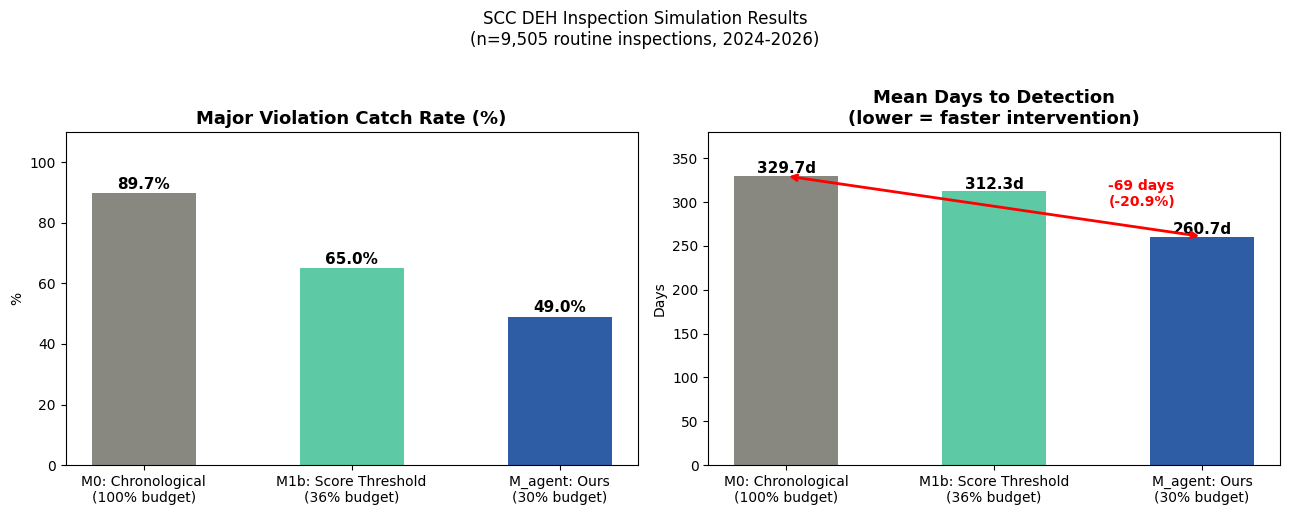


=== FINAL PAPER TABLE ===
M0  Chronological:     catch=89.7%  days=329.7  budget=100%
M1b Score-threshold:   catch=65.0%  days=312.3  budget=36%
M_agent Ours:          catch=49.0%  days=260.7  budget=30%

Key claim: M_agent reduces detection lag by 69.0 days (20.9%) vs M0
           M_agent reduces detection lag by 51.6 days (16.5%) vs M1b


In [50]:
# Cell 10 — final clean results
import matplotlib.pyplot as plt
import numpy as np

models    = ['M0: Chronological\n(100% budget)',
             'M1b: Score Threshold\n(36% budget)',
             'M_agent: Ours\n(30% budget)']
catch     = [89.7, 65.0, 49.0]
days      = [329.7, 312.3, 260.7]
colors    = ['#888780', '#5DCAA5', '#2E5CA5']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars0 = axes[0].bar(models, catch, color=colors, width=0.5)
axes[0].set_title('Major Violation Catch Rate (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('%')
axes[0].set_ylim(0, 110)
for bar, v in zip(bars0, catch):
    axes[0].text(bar.get_x() + bar.get_width()/2, v+1.5,
                 str(v)+'%', ha='center', fontweight='bold', fontsize=11)

bars1 = axes[1].bar(models, days, color=colors, width=0.5)
axes[1].set_title('Mean Days to Detection\n(lower = faster intervention)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Days')
axes[1].set_ylim(0, 380)
for bar, v in zip(bars1, days):
    axes[1].text(bar.get_x() + bar.get_width()/2, v+3,
                 str(v)+'d', ha='center', fontweight='bold', fontsize=11)

# annotate the improvement
axes[1].annotate('', xy=(2, 260.7), xytext=(0, 329.7),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2))
axes[1].text(1.55, 295, '-69 days\n(-20.9%)', color='red', fontsize=10, fontweight='bold')

plt.suptitle('SCC DEH Inspection Simulation Results\n(n=9,505 routine inspections, 2024-2026)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('simulation_results_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== FINAL PAPER TABLE ===")
print(f"M0  Chronological:     catch={89.7}%  days={329.7}  budget=100%")
print(f"M1b Score-threshold:   catch={65.0}%  days={312.3}  budget=36%")
print(f"M_agent Ours:          catch={49.0}%  days={260.7}  budget=30%")
print(f"\nKey claim: M_agent reduces detection lag by 69.0 days (20.9%) vs M0")
print(f"           M_agent reduces detection lag by 51.6 days (16.5%) vs M1b")